# Optogenetics — Visualization

This notebook loads the previously built combined DataFrame (see `optogenetics_build_dataframe.ipynb`) and runs the visualization / exploration workflows.

In [1]:
# =============================================================================
# 1. ENVIRONMENT SETUP & MODULE IMPORTS
# =============================================================================
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

MODULE_PATH = Path("/root/capsule/src/aind_dft_ephys_analysis")
if str(MODULE_PATH) not in sys.path:
    sys.path.insert(0, str(MODULE_PATH))

print(f"✅ Analysis modules loaded from: {MODULE_PATH}")

✅ Analysis modules loaded from: /root/capsule/src/aind_dft_ephys_analysis


In [40]:
from nwb_utils import NWBUtils
from optogenetics_utils import (
    create_opto_data_frame,
    find_unique_combinations,
    find_unique_stimulation,
    load_opto_data_frame,
    find_unique_values_by_conditions,
    normalize_string_columns,
    create_opto_data_frame_combined
)
from optogenetics_visualization import (
    plot_stay_switch_over_window,
    plot_rates_vs_latent,
    plot_on_off_block_rates,
)

## Load the pre-built combined DataFrame

In [3]:
combined_dataframe = load_opto_data_frame(
    csv_path='/root/capsule/scratch/combined_opto_data_frame.csv'
)
combined_dataframe = normalize_string_columns(combined_dataframe)
combined_dataframe.shape

(78600, 132)

In [41]:

combined_dataframe_o=load_opto_data_frame(csv_path = '/root/capsule/scratch/combined_opto_data_frame.csv')

combined_dataframe=create_opto_data_frame_combined(save_path='/root/capsule/scratch/combined_opto_data_frame.csv',existing_data=combined_dataframe_o)

Skipping 168 NWB file(s) already present in existing_data.


Processing NWB files:   0%|          | 0/9 [00:00<?, ?file/s]

[1/9] 843079_2026-05-14_11-41-15.nwb


/root/capsule/src/aind_dft_ephys_analysis/optogenetics_utils.py:235: UserWarning: [843079_2026-05-14_11-41-15.json] missing 33/33 latents.
  warnings.warn(


[2/9] 843079_2026-05-15_11-51-23.nwb


...

[8/9] 844033_2026-05-14_15-03-21.nwb


/root/capsule/src/aind_dft_ephys_analysis/optogenetics_utils.py:235: UserWarning: [844033_2026-05-14_15-03-21.json] missing 33/33 latents.
  warnings.warn(


[9/9] 844033_2026-05-15_14-49-14.nwb


/root/capsule/src/aind_dft_ephys_analysis/optogenetics_utils.py:235: UserWarning: [844033_2026-05-15_14-49-14.json] missing 33/33 latents.
  warnings.warn(


Combined DataFrame saved to /root/capsule/scratch/combined_opto_data_frame.csv


## Inspect unique stimulation conditions

In [42]:
find_unique_stimulation(
    combined_dataframe,
    columns=[
        'laser_on_trial', 'laser_wavelength', 'laser_location',
        'laser_duration', 'laser_start', 'laser_start_offset',
        'laser_end', 'laser_end_offset', 'laser_protocol',
        'laser_frequency', 'laser_pulse_duration',
        'session_wide_control', 'fraction_of_session', 'session_start_with',
        'session_alternation',
        'laser_1_target_areas', 'laser_2_target_areas', 'laser_rampingdown',
    ],
    include_id_lists=False,
    include={"laser_1_target_areas":["left VP GABAergic neuron inactivation"],"laser_2_target_areas":["right VP GABAergic neuron inactivation"]}
    
)

,laser_on_trial,laser_wavelength,laser_location,laser_duration,laser_start,laser_start_offset,laser_end,laser_end_offset,laser_protocol,laser_frequency,...,session_wide_control,fraction_of_session,session_start_with,session_alternation,laser_1_target_areas,laser_2_target_areas,laser_rampingdown,n_trials,n_session,n_mice
0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,on,0.5,off,on,left VP GABAergic neuron inactivation,right VP GABAergic neuron inactivation,NaN,5574,14,3
1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,on,0.5,on,on,left VP GABAergic neuron inactivation,right VP GABAergic neuron inactivation,NaN,4436,12,3
2,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,off,0.5,on,on,left VP GABAergic neuron inactivation,right VP GABAergic neuron inactivation,NaN,2297,6,3
3,1,473.0,both,1.0,trial start,0.0,NaN,0.0,sine,40.0,...,on,0.5,on,on,left VP GABAergic neuron inactivation,right VP GABAergic neuron inactivation,0.2,120,12,3
4,1,473.0,both,3.0,go cue,0.3,NaN,0.0,sine,40.0,...,on,0.5,on,on,left VP GABAergic neuron inactivation,right VP GABAergic neuron inactivation,0.2,119,12,3
5,1,473.0,both,50.0,trial start,0.0,go cue,0.0,sine,40.0,...,on,0.5,on,on,left VP GABAergic neuron inactivation,right VP GABAergic neuron inactivation,0.2,117,12,3
6,1,473.0,both,3.0,go cue,0.0,NaN,0.0,sine,40.0,...,on,0.5,on,on,left VP GABAergic neuron inactivation,right VP GABAergic neuron inactivation,0.2,116,12,3
7,1,473.0,both,3.0,go cue,0.0,NaN,0.0,sine,40.0,...,off,0.5,on,on,left VP GABAergic neuron inactivation,right VP GABAergic neuron inactivation,0.2,98,6,3
8,1,473.0,both,1.0,trial start,0.0,NaN,0.0,sine,40.0,...,off,0.5,on,on,left VP GABAergic neuron inactivation,right VP GABAergic neuron inactivation,0.2,97,6,3
9,1,473.0,both,3.0,go cue,0.0,NaN,0.0,sine,40.0,...,on,0.5,off,on,left VP GABAergic neuron inactivation,right VP GABAergic neuron inactivation,0.2,96,11,3


In [43]:
conds = {"laser_start": "Go cue", "laser_end": "Trial start"}
unique_vals = find_unique_values_by_conditions(combined_dataframe, conds, output_column="session")
print(unique_vals)

[]


## Build a `criteria` dict from one stimulation row

In [44]:
import pandas as pd

conditions = find_unique_stimulation(
    combined_dataframe,
    columns=[
        'laser_on_trial', 'laser_wavelength', 'laser_location',
        'laser_duration', 'laser_start', 'laser_start_offset',
        'laser_end', 'laser_end_offset', 'laser_protocol',
        'laser_frequency', 'laser_pulse_duration',
        'session_wide_control', 'fraction_of_session', 'session_start_with',
        'session_alternation',
        'laser_1_target_areas', 'laser_2_target_areas', 'laser_rampingdown',
    ],
    include_id_lists=False,
    include={
        "laser_1_target_areas": ["left VP GABAergic neuron inactivation"],
        "laser_2_target_areas": ["right VP GABAergic neuron inactivation"],
    },
)

'''
conditions = find_unique_stimulation(
    combined_dataframe,
    columns=[
        'laser_on_trial', 'laser_wavelength', 'laser_location',
        'laser_duration', 'laser_start', 'laser_start_offset',
        'laser_end', 'laser_end_offset', 'laser_protocol',
        'laser_frequency', 'laser_pulse_duration',
        'session_wide_control', 'fraction_of_session', 'session_start_with',
        'session_alternation',
        'laser_1_target_areas', 'laser_2_target_areas', 'laser_rampingdown',
    ],
    include_id_lists=False,
    include={
        "laser_1_target_areas": ["left VP->MD stimulation"],
        "laser_2_target_areas": ["right VP->MD stimulation"],
    },
)
'''

	

'''
conditions = find_unique_stimulation(
    combined_dataframe,
    columns=[
        'laser_on_trial', 'laser_wavelength', 'laser_location',
        'laser_duration', 'laser_start', 'laser_start_offset',
        'laser_end', 'laser_end_offset', 'laser_protocol',
        'laser_frequency', 'laser_pulse_duration',
        'session_wide_control', 'fraction_of_session', 'session_start_with',
        'session_alternation',
        'laser_1_target_areas', 'laser_2_target_areas', 'laser_rampingdown',
    ],
    include_id_lists=False,
    include={
        "laser_1_target_areas": ["left ALM inactivation"],
        "laser_2_target_areas": ["right ALM inactivation"],
    },
)
'''


'''
conditions = find_unique_stimulation(
    combined_dataframe,
    columns=[
        'laser_on_trial', 'laser_wavelength', 'laser_location','session_wide_control', 'fraction_of_session', 'session_start_with',
        'session_alternation',
        'laser_1_target_areas', 'laser_2_target_areas', 'laser_rampingdown',
    ],
    include_id_lists=False,
    include={
        "laser_1_target_areas": ["left VP GABAergic neuron inactivation"],
        "laser_2_target_areas": ["right VP GABAergic neuron inactivation"],
    },
)
'''


conditions = conditions.sort_values(
    by=["laser_1_target_areas", "laser_2_target_areas", "session_wide_control", "n_trials"],
    ascending=[True, False, False, False],
)

row = conditions.loc[4]
criteria = (
    row.drop(labels=['n_trials', 'n_session', 'n_mice'], errors='ignore')
       .where(pd.notna(row), None)
       .to_dict()
)
criteria

{'laser_on_trial': 1,
 'laser_wavelength': 473.0,
 'laser_location': 'both',
 'laser_duration': 3.0,
 'laser_start': 'go cue',
 'laser_start_offset': 0.3,
 'laser_end': None,
 'laser_end_offset': 0.0,
 'laser_protocol': 'sine',
 'laser_frequency': 40.0,
 'laser_pulse_duration': 0.002,
 'session_wide_control': 'on',
 'fraction_of_session': 0.5,
 'session_start_with': 'on',
 'session_alternation': 'on',
 'laser_1_target_areas': 'left VP GABAergic neuron inactivation',
 'laser_2_target_areas': 'right VP GABAergic neuron inactivation',
 'laser_rampingdown': 0.2}

In [45]:
conditions

,laser_on_trial,laser_wavelength,laser_location,laser_duration,laser_start,laser_start_offset,laser_end,laser_end_offset,laser_protocol,laser_frequency,...,session_wide_control,fraction_of_session,session_start_with,session_alternation,laser_1_target_areas,laser_2_target_areas,laser_rampingdown,n_trials,n_session,n_mice
0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,on,0.5,off,on,left VP GABAergic neuron inactivation,right VP GABAergic neuron inactivation,NaN,5574,14,3
1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,on,0.5,on,on,left VP GABAergic neuron inactivation,right VP GABAergic neuron inactivation,NaN,4436,12,3
3,1,473.0,both,1.0,trial start,0.0,NaN,0.0,sine,40.0,...,on,0.5,on,on,left VP GABAergic neuron inactivation,right VP GABAergic neuron inactivation,0.2,120,12,3
4,1,473.0,both,3.0,go cue,0.3,NaN,0.0,sine,40.0,...,on,0.5,on,on,left VP GABAergic neuron inactivation,right VP GABAergic neuron inactivation,0.2,119,12,3
5,1,473.0,both,50.0,trial start,0.0,go cue,0.0,sine,40.0,...,on,0.5,on,on,left VP GABAergic neuron inactivation,right VP GABAergic neuron inactivation,0.2,117,12,3
6,1,473.0,both,3.0,go cue,0.0,NaN,0.0,sine,40.0,...,on,0.5,on,on,left VP GABAergic neuron inactivation,right VP GABAergic neuron inactivation,0.2,116,12,3
9,1,473.0,both,3.0,go cue,0.0,NaN,0.0,sine,40.0,...,on,0.5,off,on,left VP GABAergic neuron inactivation,right VP GABAergic neuron inactivation,0.2,96,11,3
10,1,473.0,both,3.0,go cue,0.3,NaN,0.0,sine,40.0,...,on,0.5,off,on,left VP GABAergic neuron inactivation,right VP GABAergic neuron inactivation,0.2,95,11,3
11,1,473.0,both,1.0,trial start,0.0,NaN,0.0,sine,40.0,...,on,0.5,off,on,left VP GABAergic neuron inactivation,right VP GABAergic neuron inactivation,0.2,93,11,3
14,1,473.0,both,50.0,trial start,0.0,go cue,0.0,sine,40.0,...,on,0.5,off,on,left VP GABAergic neuron inactivation,right VP GABAergic neuron inactivation,0.2,64,11,3


## Plot rates vs. a latent variable (ITI delay sum)

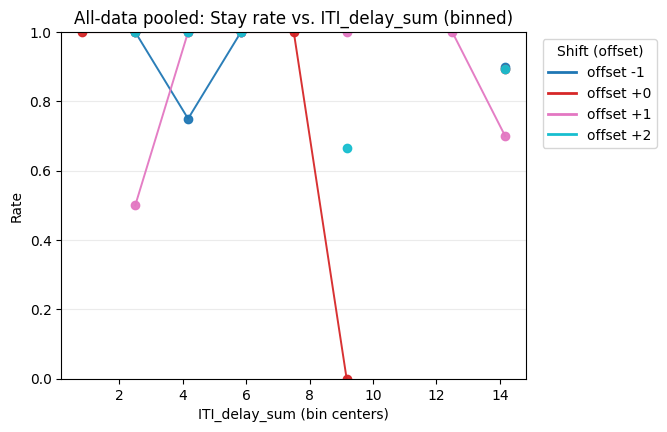

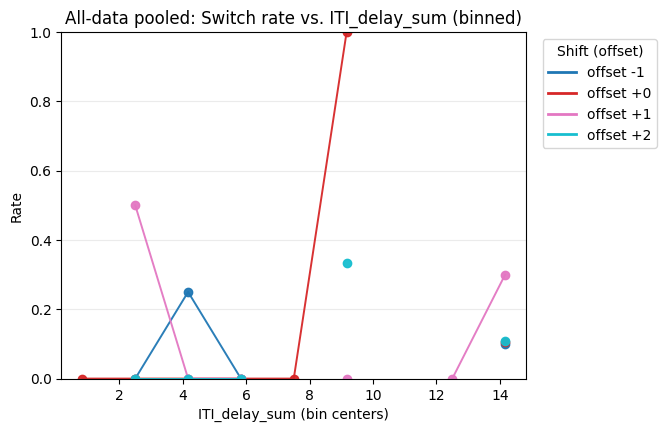

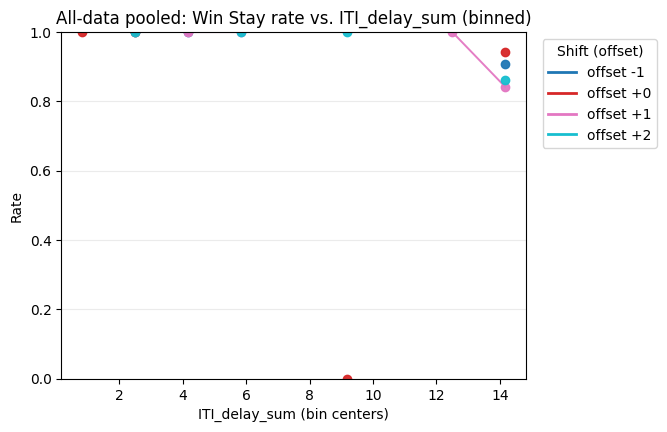

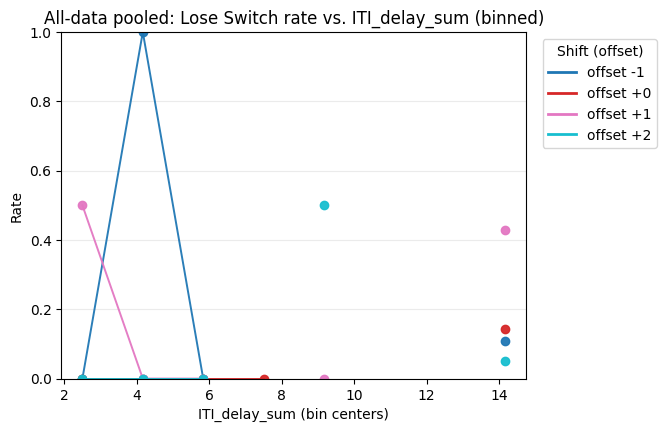

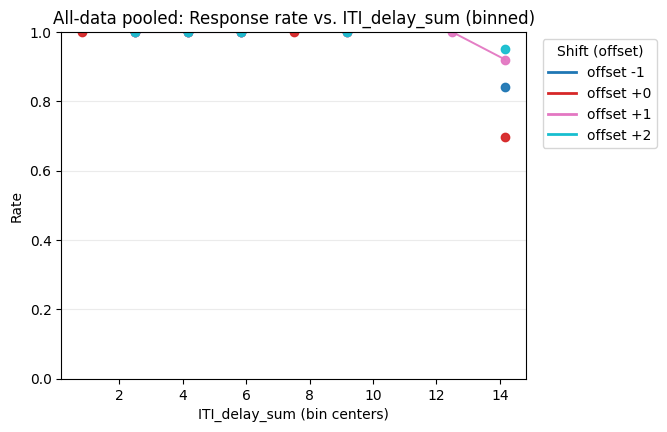

In [46]:
figs = plot_rates_vs_latent(
    combined_dataframe,
    latent_col="ITI_delay_sum",
    line_by="all",
    bins=9,
    binning="uniform",
    criteria=criteria,
    latent_range=(0, 15),
    window=[-1, 2],
)

## Stay/switch over window + rates vs. deltaQ

In [68]:

row = conditions.loc[10]
criteria = (
    row.drop(labels=['n_trials', 'n_session', 'n_mice'], errors='ignore')
       .where(pd.notna(row), None)
       .to_dict()
)
criteria

{'laser_on_trial': 1,
 'laser_wavelength': 473.0,
 'laser_location': 'both',
 'laser_duration': 3.0,
 'laser_start': 'go cue',
 'laser_start_offset': 0.3,
 'laser_end': None,
 'laser_end_offset': 0.0,
 'laser_protocol': 'sine',
 'laser_frequency': 40.0,
 'laser_pulse_duration': 0.002,
 'session_wide_control': 'on',
 'fraction_of_session': 0.5,
 'session_start_with': 'off',
 'session_alternation': 'on',
 'laser_1_target_areas': 'left VP GABAergic neuron inactivation',
 'laser_2_target_areas': 'right VP GABAergic neuron inactivation',
 'laser_rampingdown': 0.2}

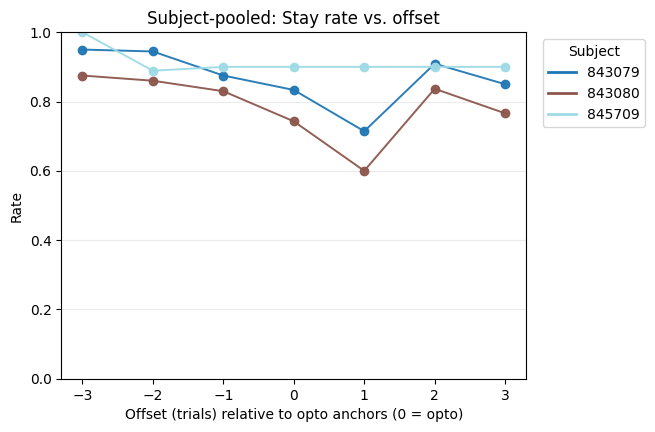

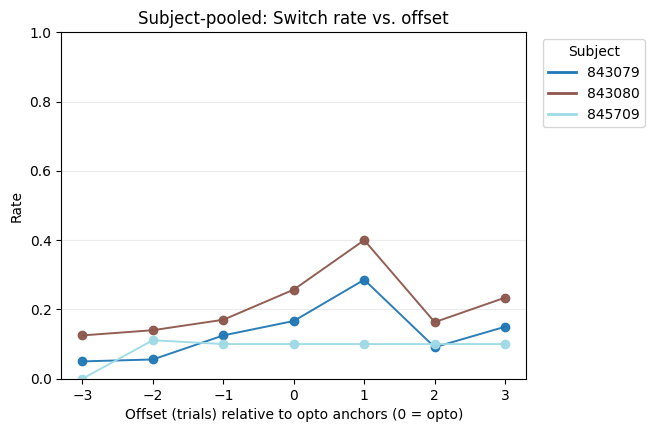

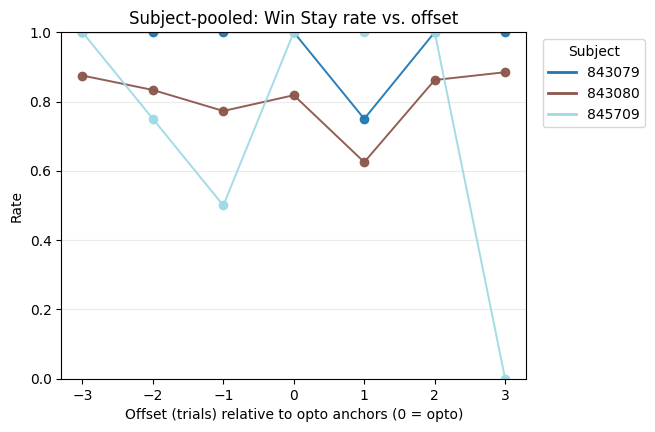

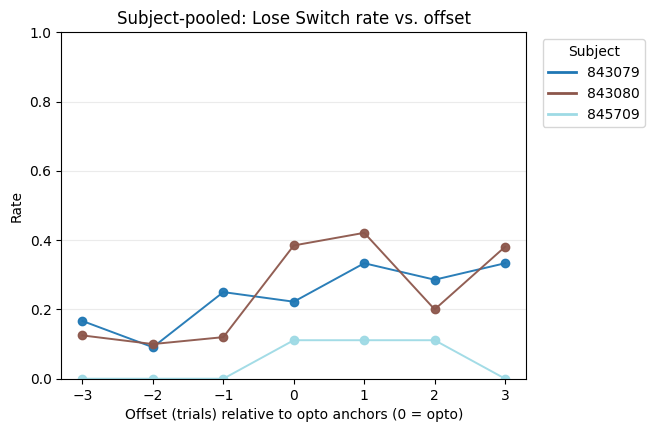

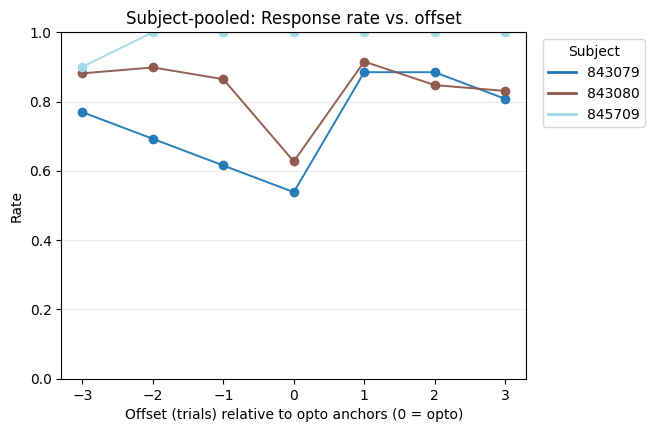

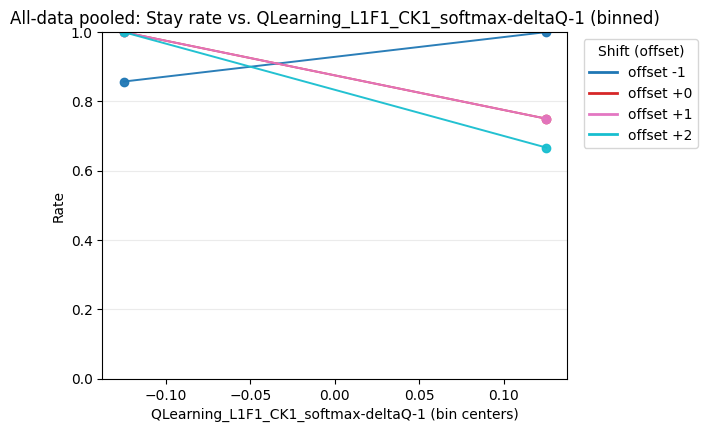

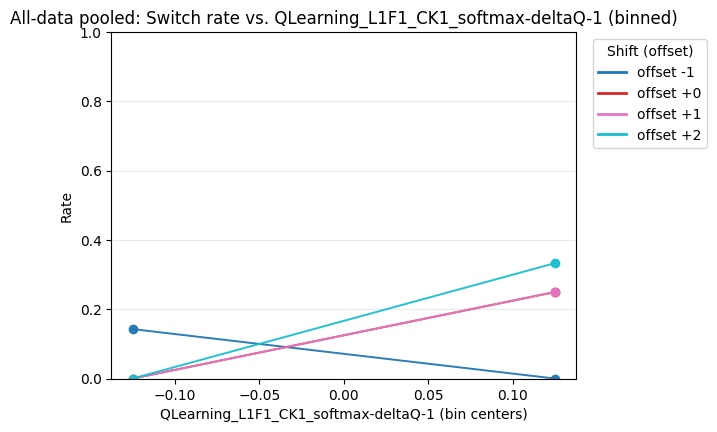

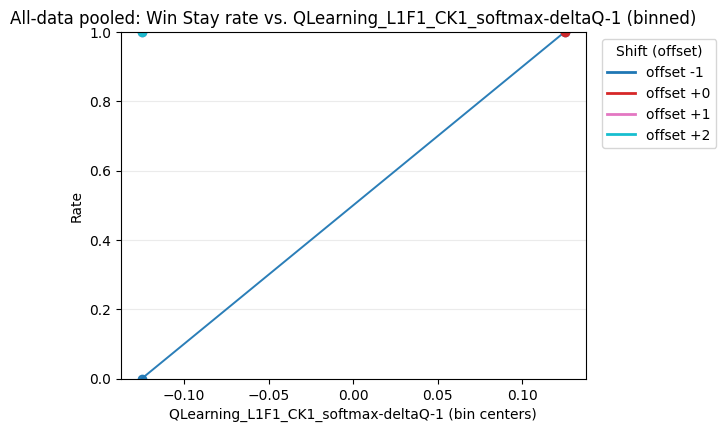

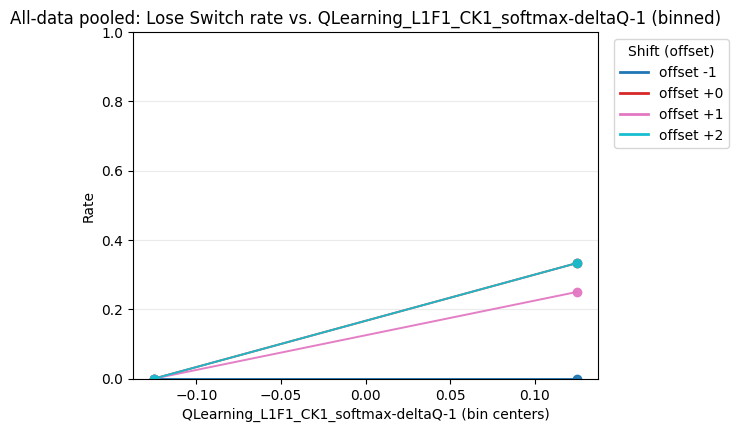

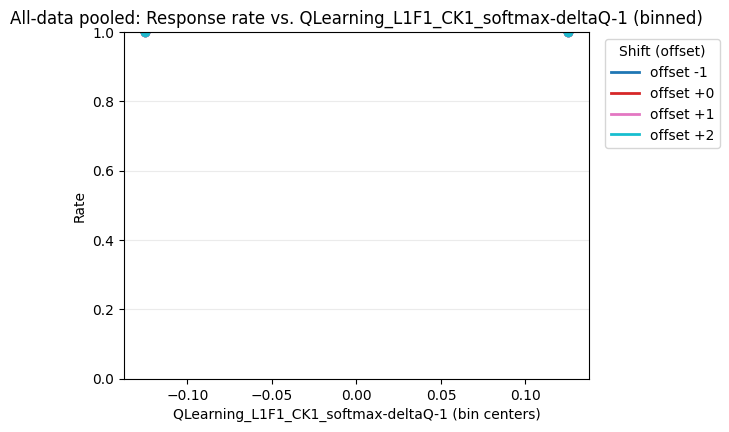

In [69]:
plot_stay_switch_over_window(
    combined_dataframe,
    criteria=criteria,
    window=[-3, 3],
    line_by='subject',
    #exclude={'subject_id':[779310,795396,795710]}
)

figs = plot_rates_vs_latent(
    combined_dataframe,
    latent_col="QLearning_L1F1_CK1_softmax-deltaQ-1",
    line_by="all",
    bins=8,
    binning="uniform",
    criteria=criteria,
    window=[-1, 2],
    #exclude={'subject_id':[844033,778149]}
)

{'stay': <Figure size 500x450 with 1 Axes>,
 'switch': <Figure size 500x450 with 1 Axes>,
 'win_stay': <Figure size 500x450 with 1 Axes>,
 'lose_switch': <Figure size 500x450 with 1 Axes>,
 'response': <Figure size 500x450 with 1 Axes>}

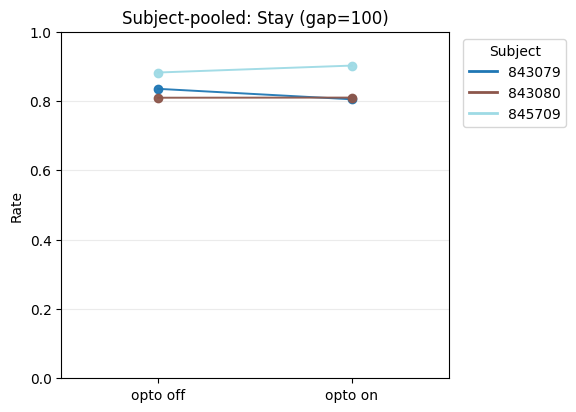

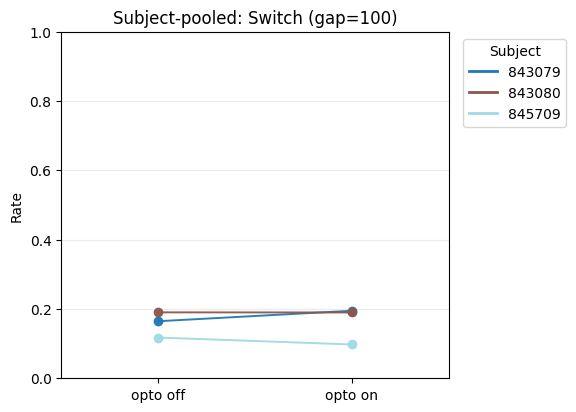

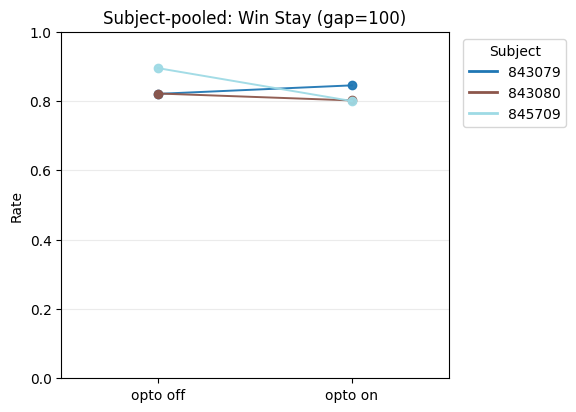

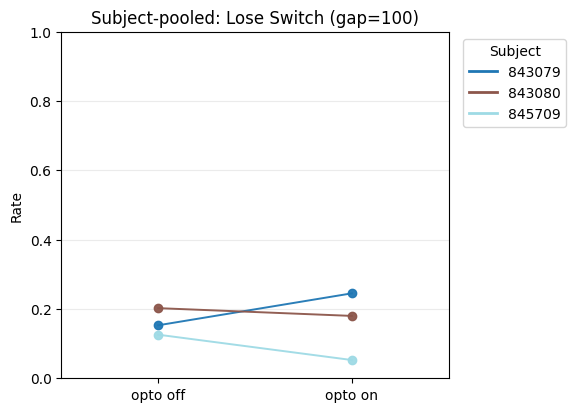

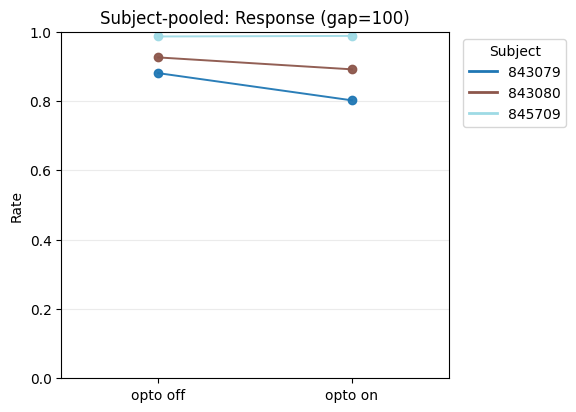

In [57]:
plot_on_off_block_rates(
    combined_dataframe,
    criteria=criteria,
    line_by='subject',
)